<a href="https://colab.research.google.com/github/varrunavi/cb2330-portfolio/blob/main/05_parameter_estimation/exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/05_parameter_estimation/exercise.ipynb)

# Session 05 - Parameter Estimation and Maximum Likelihood

In this exercise we fit the video's model to its measurement: colonies counted on 25 dishes, a Poisson proposed for those counts, and a rate estimated by scoring 400 candidates. We write one dish's probability, multiply it over 25 dishes, take logs, sweep 400 candidates, and read off where the best score sits, which is the page's arg min. Then we fit the shelf page's normal, which has two parameters, to the diameters of the colonies.

I've written the data, the check cells and the figures already.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`, with its figures rendered on the published page and a sentence under them saying what they show.

---

# Part A

The data are colonies counted on 25 dishes, in colonies per dish. `math` supplies $e^{x}$ as `math.exp` and $\ln x$ as `math.log`.

In [1]:
import math
import matplotlib.pyplot as plt

counts = [6, 9, 3, 9, 8, 11, 8, 13, 5, 9, 9, 6, 7, 14, 7, 7, 8, 7, 3, 10, 7, 15, 11, 7, 7]
N = len(counts)                                   # dishes
print(N, "dishes, colonies per dish:", counts)


25 dishes, colonies per dish: [6, 9, 3, 9, 8, 11, 8, 13, 5, 9, 9, 6, 7, 14, 7, 7, 8, 7, 3, 10, 7, 15, 11, 7, 7]


## 1. One dish

This section is aimed at the height of the bar. A model already assigns a probability to an observed count, and read with the count fixed and the rate varied that probability is the likelihood. We write the Poisson and score the page's dish of 12 colonies at its two candidates, 8 and 12.

$$p(x \mid \theta) = \frac{\theta^{x} e^{-\theta}}{x!}$$

`factorial` is written, as $1 \cdot 2 \cdots x$. `poisson` takes a count and a candidate rate and returns the probability of that count. The check cell tests a dish of 12 colonies at 8 and 12, as on the page, and that probabilities sum to 1 over counts.

**Fill the gap to write a Poisson.** `poisson` receives `x` and `theta` and returns the formula above. `**` is a power, `math.exp(-theta)` is $e^{-\theta}$, and `factorial(x)` is $x!$.

In [3]:
def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total


def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x colonies at rate theta."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    return theta**x*math.exp(-theta)/factorial(x)
    pass


In [4]:
assert factorial(0) == 1 and factorial(5) == 120
assert abs(poisson(0, 1.0) - math.exp(-1)) < 1e-12          # theta^0 / 0! = 1
assert abs(poisson(12, 8.0) - 0.048127) < 1e-6               # the page's x = 12 at theta_1 = 8
assert abs(poisson(12, 12.0) - 0.114368) < 1e-6              # and at theta_2 = 12, greater
total = 0.0
for x in range(60):
    total = total + poisson(x, 8.0)
assert abs(total - 1.0) < 1e-9, "p(x | theta) sums to 1 over the counts x"
print("ok  p(12 | 8) =", round(poisson(12, 8.0), 4), " p(12 | 12) =", round(poisson(12, 12.0), 4))


ok  p(12 | 8) = 0.0481  p(12 | 12) = 0.1144


Below is the page's picture: one dish with 12 colonies, and $\theta$ swept. The horizontal axis is $\theta$ and not $x$, so the curve is $L(\theta) = p(12 \mid \theta)$, with 8 and 12 marked.

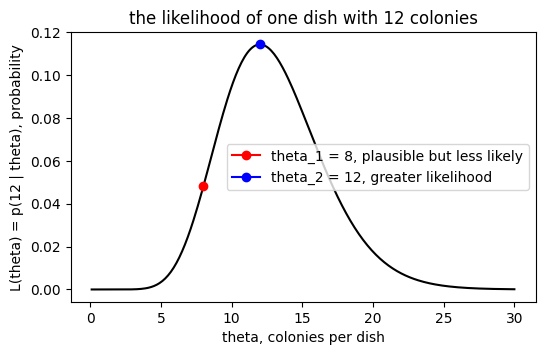

In [5]:
thetas = [0.0] * 300
heights = [0.0] * 300
for j in range(300):
    thetas[j] = 0.1 * (j + 1)
    heights[j] = poisson(12, thetas[j])
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thetas, heights, color="black")
ax.plot([8.0], [poisson(12, 8.0)], marker="o", color="red", label="theta_1 = 8, plausible but less likely")
ax.plot([12.0], [poisson(12, 12.0)], marker="o", color="blue", label="theta_2 = 12, greater likelihood")
ax.set_xlabel("theta, colonies per dish")
ax.set_ylabel("L(theta) = p(12 | theta), probability")
ax.set_title("the likelihood of one dish with 12 colonies")
ax.legend()
plt.show()


## 2. Many dishes

Here we turn one dish into 25. Dishes are plated independently, so a set's probability is a product over its members, and that product is the likelihood of the sample. It gets small fast, and a cell after the check shows how small.

$$L(\theta) = \prod_{i=1}^{N} p(x_i \mid \theta)$$

`likelihood` takes a list of counts and a candidate rate and returns their product. The check cell tests three dishes multiplied by hand, and a cell after that runs 1000 dishes, the counts repeated 40 times.

**Fill the gap to multiply over dishes.** `likelihood` receives `counts` and `theta`, with `total` set up at 1. Write a loop over `counts` that multiplies `total` by `poisson(x, theta)` per pass.

In [14]:
def likelihood(counts, theta):
    """L(theta) = the product over dishes of p(x_i | theta)."""
    total = 1.0
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    for x in counts:
      total*=poisson(x, theta)

    return total


In [15]:
three = [6, 9, 3]
by_hand = poisson(6, 8.0) * poisson(9, 8.0) * poisson(3, 8.0)
assert abs(likelihood(three, 8.0) - by_hand) < 1e-15
assert likelihood(counts, 8.0) < likelihood(counts, 8.24), "the mean is the better candidate"
print("ok  L(8) for 3 dishes =", by_hand)
print("    L(8) for 25 dishes =", likelihood(counts, 8.0))


ok  L(8) for 3 dishes = 0.0004338158550242309
    L(8) for 25 dishes = 1.744222942085317e-27


In [16]:
# the same product on 1000 dishes: the counts repeated 40 times
many = []
for k in range(40):
    for x in counts:
        many.append(x)
print(len(many), "dishes:  L(8) =", likelihood(many, 8.0))


1000 dishes:  L(8) = 0.0


## 3. Negative log-likelihood

Taking logs turns a product into a sum, which a computer can carry where products go to zero, and a minus sign turns the score into a loss, as optimisers expect. We write that sum and check that it agrees with the log of the product wherever the product survives.

$$\mathrm{NLL}(\theta) = -\sum_{i=1}^{N} \ln p(x_i \mid \theta)$$

`nll` takes the same two arguments and returns a sum. The check cell tests that it equals $-\ln$ of section 2's product on three dishes, and that it stays finite on 1000.

**Fill the gap to add logs.** `nll` receives the same two arguments, with `total` set up at 0. Write a loop over `counts` that subtracts `math.log(poisson(x, theta))` from `total` per pass.

In [17]:
def nll(counts, theta):
    """NLL(theta) = - the sum over dishes of log p(x_i | theta)."""
    total = 0.0
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    for x in counts:
      total-= math.log(poisson(x,theta))
    return total


In [18]:
assert abs(nll(three, 8.0) + math.log(likelihood(three, 8.0))) < 1e-9, "the log of the product is the sum of the logs"
assert nll(counts, 8.0) > nll(counts, 8.24), "smaller is better"
assert nll(many, 8.0) < 1e9, "finite where the product underflowed"
print("ok  NLL(8) for 25 dishes =", round(nll(counts, 8.0), 3), " for 1000 dishes =", round(nll(many, 8.0), 3))


ok  NLL(8) for 25 dishes = 61.613  for 1000 dishes = 2464.54


## 4. Candidate sweep

The estimate is whichever candidate scores best, and the page's brute-force route scores candidates across a range we choose. Two lists sit in this section and they are not one list: 25 counts, which were measured, and 400 candidate rates, which we made up. An outer loop runs over the candidates, and an inner sum, inside `nll`, runs over the counts.

$$\mathrm{NLL}(\theta_j), \qquad \theta_j = 0.05\,j, \qquad j = 1, \dots, M, \qquad M = 400$$

`candidates` holds 400 candidate rates and `scores` holds a score per candidate. The check cell tests candidate 160's score, which is $\theta = 8$, and that the range scores worse at its ends than in the middle. The figure is the likelihood curve, $\mathrm{NLL}(\theta_j)$ against $\theta_j$.

**Fill the gap to score every candidate.** `candidates` and `scores` are set up, `scores` as `M` zeros. Write a loop over `range(M)` that stores `nll(counts, candidates[j])` in `scores[j]`.

In [20]:
M = 400
candidates = [0.0] * M
for j in range(M):
    candidates[j] = 0.05 * (j + 1)                # 0.05 to 20.00 colonies per dish

scores = [0.0] * M
# ⭐⭐⭐ Your code here ⭐⭐⭐
for j in range(M):
  scores[j]=nll(counts, candidates[j])

In [21]:
assert len(scores) == M
assert abs(candidates[159] - 8.0) < 1e-12
assert abs(scores[159] - nll(counts, 8.0)) < 1e-12, "the score at candidate 160 is NLL at theta = 8"
assert scores[0] > scores[159] and scores[399] > scores[159], "the edges of the range score worse than the middle"
print("ok  400 candidates scored")


ok  400 candidates scored


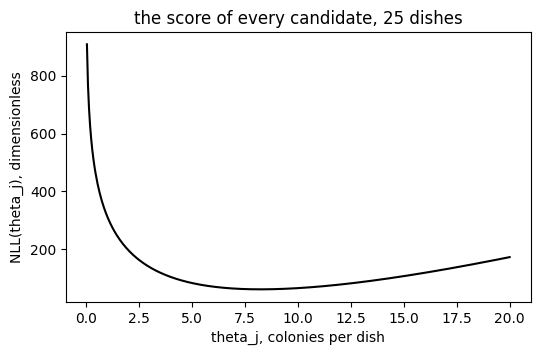

In [22]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(candidates, scores, color="black")
ax.set_xlabel("theta_j, colonies per dish")
ax.set_ylabel("NLL(theta_j), dimensionless")
ax.set_title("the score of every candidate, 25 dishes")
plt.show()


## 5. Estimate

Arg min is this section's construction: where the smallest score sits, and not the score itself. The page's exam problem turns on that difference. We write the search as a loop and compare its result with the sample mean, which the page derived by calculus as a Poisson's estimate.

$$\hat{\theta} = \arg\min_{\theta} \mathrm{NLL}(\theta)$$

`position_of_min` takes a list and returns the position of its smallest entry. `theta_hat` is the candidate at that position. The check cell compares `theta_hat` with the sample mean, which is what the page's analytical route gives.

**Fill the gap to find where the minimum sits.** `position_of_min` receives `values` and returns `best`, set up at 0. Write a loop over `range(len(values))` that sets `best` to `j` whenever `values[j] < values[best]`.

In [29]:
def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    for j in range(len(values)):
      if values[j]< values[best]:
        best=j
    return best

theta_hat = candidates[position_of_min(scores)]


In [30]:
mean = 0.0
for x in counts:
    mean = mean + x / N
assert position_of_min([3.0, 1.0, 2.0]) == 1
assert abs(theta_hat - mean) <= 0.025 + 1e-9, "the sweep lands on the sample mean, to half a grid step"
print("ok  theta_hat =", theta_hat, "colonies per dish;  sample mean =", mean)
print("    NLL at the minimum =", round(scores[position_of_min(scores)], 3), " (the score, not the estimate)")


ok  theta_hat = 8.25 colonies per dish;  sample mean = 8.240000000000002
    NLL at the minimum = 61.525  (the score, not the estimate)


## 6. Two parameters

A normal is the shelf page's model for a sum of many small independent contributions, and the video's example is a length measured with a ruler. It has a mean $\mu$ and a standard deviation $\sigma$, so a candidate is now a pair, and the candidates form a grid. A colony per dish was measured, and we score pairs of $\mu$ and $\sigma$ against its 25 diameters and keep the pair with the smallest score. I've given less here than in sections 1 to 5, so laying out a grid and searching it is ours to decide.

$$f(x \mid \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-(x-\mu)^2 / 2\sigma^2}, \qquad \mathrm{NLL}(\mu, \sigma) = -\sum_{i=1}^{N} \ln f(x_i \mid \mu, \sigma), \qquad (\hat{\mu}, \hat{\sigma}) = \arg\min_{\mu,\,\sigma} \mathrm{NLL}(\mu, \sigma)$$

`diameters` holds a colony's diameter per dish, in mm. The check cell compares $\hat{\mu}$ with the sample mean and $\hat{\sigma}$ with the standard deviation. The figure draws the score over both parameters as contours, lines of equal score as on a map, with the estimate marked.

**Fill the gaps to fit $\mu$ and $\sigma$ by grid search.** Signatures of `normal` and `nll_normal` are given, and so are `mu_hat` and `sigma_hat`, set up at 0. Write `normal` from the formula, with `(2 * math.pi) ** 0.5` for $\sqrt{2\pi}$, and `nll_normal` as section 3's `nll` with a second parameter. Then score pairs on a grid with a loop over $\mu$ and a loop over $\sigma$ inside it, and leave the best pair in `mu_hat` and `sigma_hat`, keeping a best score so far as `position_of_min` kept a best position. The check allows 0.03 mm, so a spacing of 0.02 mm or finer passes. $\mu$ from 1 to 4 mm and $\sigma$ from 0.1 to 1 mm cover the data, and a $\sigma$ much below 0.1 mm stops the run with `math domain error`.

In [35]:
# the diameter of one colony per dish, measured with a ruler, in mm
diameters = [2.0, 2.0, 2.6, 1.6, 2.3, 1.6, 2.8, 2.5, 2.9, 2.2, 2.5, 2.3, 2.1,
             2.5, 2.0, 2.3, 2.6, 2.4, 2.3, 3.2, 2.4, 2.2, 2.5, 2.2, 2.3]


def normal(x, mu, sigma):
    """f(x | mu, sigma)  the density of a diameter x, in 1/mm."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    return 1/(sigma*(2*math.pi)**0.5)*math.exp(-(x-mu)**2/(2*sigma**2))
    pass


def nll_normal(diameters, mu, sigma):
    """NLL(mu, sigma) = - the sum over dishes of log f(x_i | mu, sigma)."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    total=0.0
    for x in diameters:
      total=total-math.log(normal(x,mu,sigma))

    return total



mu_hat = 0.0
sigma_hat = 0.0
best_score = math.inf

step = 0.01
for i in range(301):            # mu: 1.00 .. 4.00
    mu = 1 + i * step
    for j in range(91):         # sigma: 0.10 .. 1.00
        sigma = 0.1 + j * step
        score = nll_normal(diameters, mu, sigma)
        if score < best_score:
            best_score = score
            mu_hat = mu
            sigma_hat = sigma

print(mu_hat, sigma_hat, best_score)
# ⭐⭐⭐ Your code here ⭐⭐⭐



2.33 0.35 9.276889809486608


In [36]:
mean_d = 0.0
for x in diameters:
    mean_d = mean_d + x / len(diameters)
variance_d = 0.0
for x in diameters:
    variance_d = variance_d + (x - mean_d) ** 2 / len(diameters)
sd_d = variance_d ** 0.5
assert abs(normal(2.0, 2.0, 1.0) - 1 / (2 * math.pi) ** 0.5) < 1e-12, "the peak height of a normal with sigma = 1"
assert abs(nll_normal([2.0], 2.0, 1.0) - 0.5 * math.log(2 * math.pi)) < 1e-12
assert abs(mu_hat - mean_d) <= 0.03, "mu_hat lands on the sample mean"
assert abs(sigma_hat - sd_d) <= 0.03, "sigma_hat lands on the standard deviation, with 1/N"
print("ok  mu_hat =", round(mu_hat, 3), "mm;  sample mean =", round(mean_d, 3), "mm")
print("    sigma_hat =", round(sigma_hat, 3), "mm;  standard deviation =", round(sd_d, 3), "mm")


ok  mu_hat = 2.33 mm;  sample mean = 2.332 mm
    sigma_hat = 0.35 mm;  standard deviation = 0.351 mm


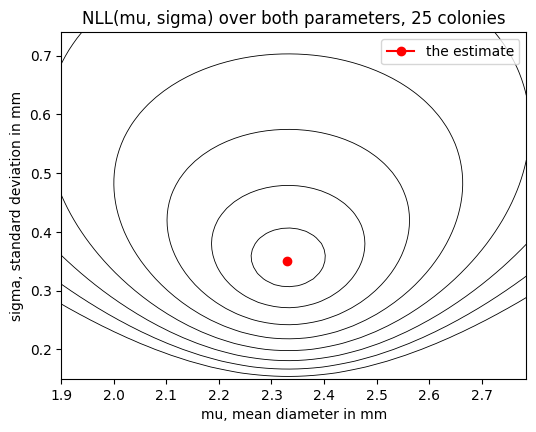

In [37]:
view_mu = [0.0] * 60
view_sigma = [0.0] * 60
surface = []                                      # a row per sigma, a column per mu
for b in range(60):
    view_sigma[b] = 0.15 + 0.01 * b
    row = [0.0] * 60
    for a in range(60):
        view_mu[a] = 1.9 + 0.015 * a
        row[a] = nll_normal(diameters, view_mu[a], view_sigma[b])
    surface.append(row)
levels = [0.0] * 8                                # contours 0.5, 2, 4.5, 8, ... above the score at the estimate
for k in range(8):
    levels[k] = nll_normal(diameters, mu_hat, sigma_hat) + 0.5 * (k + 1) ** 2
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.contour(view_mu, view_sigma, surface, levels=levels, colors="black", linewidths=0.6)
ax.plot([mu_hat], [sigma_hat], marker="o", color="red", label="the estimate")
ax.set_xlabel("mu, mean diameter in mm")
ax.set_ylabel("sigma, standard deviation in mm")
ax.set_title("NLL(mu, sigma) over both parameters, 25 colonies")
ax.legend()
plt.show()


---

# Part B

In Part B the object is an oligonucleotide's binding time, the fitting page's continuous example, and the model is an exponential density. Three identical lines fit it, with a different function called inside them. That is the shelf page's claim: a fitted distribution is a claim about a mechanism, and the machinery does not care which.

Part B is optional and done outside the session. One route is enough.

- **Three lines on a density.** Below is this route, already written: binding times of 20 molecules, an exponential density in place of the Poisson, and an identical sweep. The check is that the estimate equals 1 over the mean wait, which is what calculus gives for this model.
- **The page's exam-style problem.** A rate rising and falling with time of day, $\theta(t) = 20\,(1 + 0.8\cos(2\pi t / T))$, with the period $T$ as the parameter. `scipy.stats.poisson.logpmf` replaces `poisson` and $T$ is swept. The page's answer is 24 hours.
- **A culture that clumps.** Cells sticking together load some dishes and leave others empty, so count variance runs above count mean, which a Poisson cannot do since its variance equals its mean. The negative binomial from the shelf carries a second parameter, and section 6's grid over two parameters scores it.
- **A recovery test.** Counts generated at a rate we choose, with the generator and partition rule from the Monte Carlo session, and a sweep whose peak is read against that rate. With 5 dishes the curve is broad, with 25 narrow, and the peak sits near the true rate and not on it.

In [31]:
# binding times of an oligonucleotide, in seconds, 20 molecules
times = [0.9, 2.4, 0.3, 1.7, 4.1, 0.6, 1.2, 3.3, 0.8, 2.0, 1.5, 0.2, 2.8, 1.1, 0.5, 1.9, 3.7, 0.7, 1.4, 2.6]


def exponential(x, theta):
    """f(x | theta) = theta e^(-theta x)  the density of a wait x at rate theta per second."""
    return theta * math.exp(-theta * x)


def nll_exponential(times, theta):
    total = 0.0
    for x in times:
        total = total - math.log(exponential(x, theta))
    return total


rates = [0.0] * M
scores_b = [0.0] * M
for j in range(M):
    rates[j] = 0.01 * (j + 1)                     # 0.01 to 4.00 per second
    scores_b[j] = nll_exponential(times, rates[j])
rate_hat = rates[position_of_min(scores_b)]


ok  rate_hat = 0.59 per second;  1 / mean wait = 0.5935


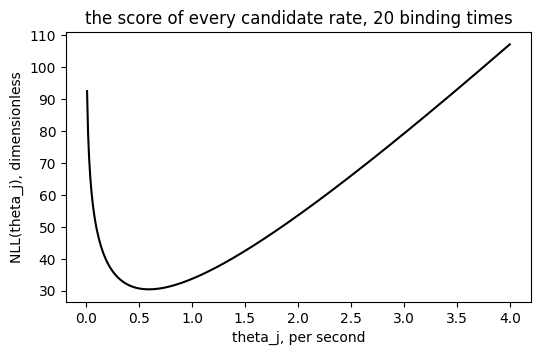

In [32]:
mean_time = 0.0
for x in times:
    mean_time = mean_time + x / len(times)
assert abs(rate_hat - 1 / mean_time) <= 0.005 + 1e-9, "for the exponential the estimate is 1 over the mean wait"
print("ok  rate_hat =", rate_hat, "per second;  1 / mean wait =", round(1 / mean_time, 4))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(rates, scores_b, color="black")
ax.set_xlabel("theta_j, per second")
ax.set_ylabel("NLL(theta_j), dimensionless")
ax.set_title("the score of every candidate rate, 20 binding times")
plt.show()
